In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = "C:/CustomerIQ/Data/Raw/customerIQ_customer_churn_dataset.csv"

df = pd.read_csv(DATA_PATH)



In [28]:
df.shape

(10050, 15)

In [29]:
df.head()

,customer_id,age,gender,location,tenure_months,monthly_spend,total_spend,login_frequency,support_tickets,product_usage,subscription_type,payment_method,discount_used,churn,customer_lifetime_value
0,C100000,56.0,Female,Mumbai,40,1008.23,43296.89,20.0,1,68.0,Monthly,Debit Card,1,0,45804.53
1,C100001,69.0,Male,Delhi,31,1716.53,52968.01,20.0,3,87.0,Monthly,UPI,0,0,92328.73
2,C100002,46.0,Female,Mumbai,65,1035.82,72203.52,23.0,7,88.0,Monthly,Wallet,1,0,83848.62
3,C100003,32.0,Male,Other,39,2622.21,107971.82,13.0,1,68.0,Annual,UPI,0,0,126076.33
4,C100004,60.0,Male,Pune,24,2117.73,49767.32,4.0,2,80.0,Monthly,Debit Card,1,0,72619.73


In [30]:
df.columns

Index(['customer_id', 'age', 'gender', 'location', 'tenure_months',
       'monthly_spend', 'total_spend', 'login_frequency', 'support_tickets',
       'product_usage', 'subscription_type', 'payment_method', 'discount_used',
       'churn', 'customer_lifetime_value'],
      dtype='str')

In [31]:
df.dtypes

customer_id                    str
age                        float64
gender                         str
location                       str
tenure_months                int64
monthly_spend              float64
total_spend                float64
login_frequency            float64
support_tickets              int64
product_usage              float64
subscription_type              str
payment_method                 str
discount_used                int64
churn                        int64
customer_lifetime_value    float64
dtype: object

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              10050 non-null  str    
 1   age                      9949 non-null   float64
 2   gender                   10050 non-null  str    
 3   location                 10050 non-null  str    
 4   tenure_months            10050 non-null  int64  
 5   monthly_spend            9950 non-null   float64
 6   total_spend              10050 non-null  float64
 7   login_frequency          9950 non-null   float64
 8   support_tickets          10050 non-null  int64  
 9   product_usage            9949 non-null   float64
 10  subscription_type        10050 non-null  str    
 11  payment_method           10050 non-null  str    
 12  discount_used            10050 non-null  int64  
 13  churn                    10050 non-null  int64  
 14  customer_lifetime_value  10050 no

In [33]:
df.isnull().sum()

customer_id                  0
age                        101
gender                       0
location                     0
tenure_months                0
monthly_spend              100
total_spend                  0
login_frequency            100
support_tickets              0
product_usage              101
subscription_type            0
payment_method               0
discount_used                0
churn                        0
customer_lifetime_value      0
dtype: int64

In [34]:
missing_percentage = (
    df.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nMissing Value Percentage:")
display(missing_percentage)


Missing Value Percentage:


age                        1.004975
product_usage              1.004975
monthly_spend              0.995025
login_frequency            0.995025
location                   0.000000
gender                     0.000000
customer_id                0.000000
total_spend                0.000000
tenure_months              0.000000
support_tickets            0.000000
subscription_type          0.000000
payment_method             0.000000
discount_used              0.000000
churn                      0.000000
customer_lifetime_value    0.000000
dtype: float64

In [35]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 50


In [36]:
duplicate_customer_ids = df["customer_id"].duplicated().sum()
print(f"Duplicate customer IDs: {duplicate_customer_ids}")

Duplicate customer IDs: 50


In [37]:
duplicate_customer_records = df[
    df["customer_id"].duplicated(keep=False)
]

print(duplicate_customer_records)

      customer_id   age  gender   location  tenure_months  monthly_spend  \
35        C100035  45.0    Male  Hyderabad             50        1194.15   
39        C100039  68.0  Female     Mumbai             16        2510.55   
251       C100251  34.0  Female       Pune             60        1511.24   
321       C100321  25.0    Male  Bengaluru             35        2021.49   
439       C100439  62.0  Female     Mumbai             40        2548.69   
...           ...   ...     ...        ...            ...            ...   
10045     C100039  68.0  Female     Mumbai             16        2510.55   
10046     C104819  67.0    Male    Kolkata             59        2278.15   
10047     C103465  29.0    Male      Delhi             17        2500.57   
10048     C101760  32.0  Female     Mumbai             50        2502.16   
10049     C102304  45.0  Female    Kolkata             23         881.53   

       total_spend  login_frequency  support_tickets  product_usage  \
35        60554.

In [38]:
df.describe()

,age,tenure_months,monthly_spend,total_spend,login_frequency,support_tickets,product_usage,discount_used,churn,customer_lifetime_value
count,9949.000000,10050.000000,9950.000000,10050.000000,9950.000000,10050.000000,9949.000000,10050.000000,10050.000000,10050.000000
mean,44.039602,36.530746,1864.987437,67948.348856,14.859598,2.257811,71.107347,0.372935,0.025572,92778.231514
std,15.208438,20.861434,648.250335,47517.647781,6.867592,1.516585,20.281982,0.483609,0.157863,40766.519063
min,18.000000,1.000000,399.000000,430.110000,1.000000,0.000000,5.000000,0.000000,0.000000,4362.610000
25%,31.000000,18.000000,1419.010000,28142.885000,10.000000,1.000000,57.000000,0.000000,0.000000,61183.305000
50%,44.000000,37.000000,1859.945000,60490.415000,15.000000,2.000000,72.000000,0.000000,0.000000,86848.120000
75%,57.000000,55.000000,2305.967500,99308.892500,20.000000,3.000000,87.000000,1.000000,0.000000,119281.102500
max,70.000000,72.000000,4263.380000,293223.600000,35.000000,10.000000,100.000000,1.000000,1.000000,272953.830000


In [39]:
df["churn"].value_counts()

churn
0    9793
1     257
Name: count, dtype: int64

In [40]:
churn_rate = df["churn"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 2.56%


In [52]:
categorical_columns = [
    "gender",
    "location",
    "subscription_type",
    "payment_method"
]

print(categorical_columns)

['gender', 'location', 'subscription_type', 'payment_method']


In [53]:

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- gender ---
gender
Female    4961
Male      4891
Other      198
Name: count, dtype: int64

--- location ---
location
Hyderabad    2209
Bengaluru    1676
Mumbai       1352
Pune         1217
Delhi        1195
Chennai       981
Kolkata       712
Other         708
Name: count, dtype: int64

--- subscription_type ---
subscription_type
Monthly      5547
Annual       2543
Quarterly    1960
Name: count, dtype: int64

--- payment_method ---
payment_method
UPI              3056
Credit Card      2731
Debit Card       2042
Bank Transfer    1547
Wallet            674
Name: count, dtype: int64


In [55]:
for column in categorical_columns:
    churn_by_category = pd.crosstab(
        df[column],
        df["churn"],
        normalize="index"
    ) * 100

    print(f"\n--- {column} vs Churn ---")
    print(churn_by_category)


--- gender vs Churn ---
churn           0         1
gender                     
Female  97.339246  2.660754
Male    97.587405  2.412595
Other   96.464646  3.535354

--- location vs Churn ---
churn              0         1
location                      
Bengaluru  97.613365  2.386635
Chennai    96.839959  3.160041
Delhi      97.991632  2.008368
Hyderabad  97.193300  2.806700
Kolkata    97.050562  2.949438
Mumbai     97.411243  2.588757
Other      98.022599  1.977401
Pune       97.534922  2.465078

--- subscription_type vs Churn ---
churn                      0         1
subscription_type                     
Annual             98.151789  1.848211
Monthly            97.295836  2.704164
Quarterly          96.938776  3.061224

--- payment_method vs Churn ---
churn                   0         1
payment_method                     
Bank Transfer   97.672915  2.327085
Credit Card     98.169169  1.830831
Debit Card      96.816846  3.183154
UPI             97.218586  2.781414
Wallet          96

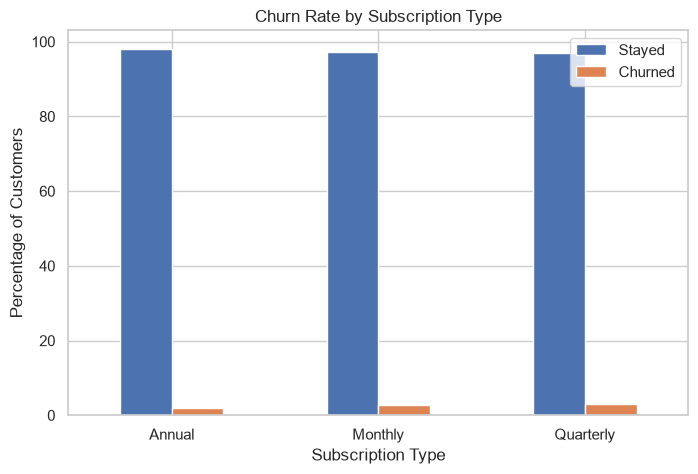

In [58]:
subscription_churn = pd.crosstab(
    df["subscription_type"],
    df["churn"],
    normalize="index"
) * 100

subscription_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])

plt.show()

In [43]:
numerical_columns = [
    "age",
    "tenure_months",
    "monthly_spend",
    "total_spend",
    "login_frequency",
    "support_tickets",
    "product_usage",
    "customer_lifetime_value"
]
df[numerical_columns].describe()


,age,tenure_months,monthly_spend,total_spend,login_frequency,support_tickets,product_usage,customer_lifetime_value
count,9949.000000,10050.000000,9950.000000,10050.000000,9950.000000,10050.000000,9949.000000,10050.000000
mean,44.039602,36.530746,1864.987437,67948.348856,14.859598,2.257811,71.107347,92778.231514
std,15.208438,20.861434,648.250335,47517.647781,6.867592,1.516585,20.281982,40766.519063
min,18.000000,1.000000,399.000000,430.110000,1.000000,0.000000,5.000000,4362.610000
25%,31.000000,18.000000,1419.010000,28142.885000,10.000000,1.000000,57.000000,61183.305000
50%,44.000000,37.000000,1859.945000,60490.415000,15.000000,2.000000,72.000000,86848.120000
75%,57.000000,55.000000,2305.967500,99308.892500,20.000000,3.000000,87.000000,119281.102500
max,70.000000,72.000000,4263.380000,293223.600000,35.000000,10.000000,100.000000,272953.830000


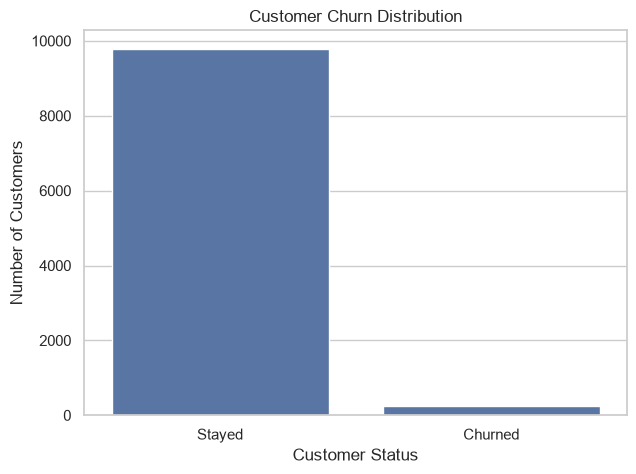

In [11]:
churn_labels = df["churn"].map({
    0: "Stayed",
    1: "Churned"
})

plt.figure(figsize=(7, 5))

sns.countplot(x=churn_labels)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

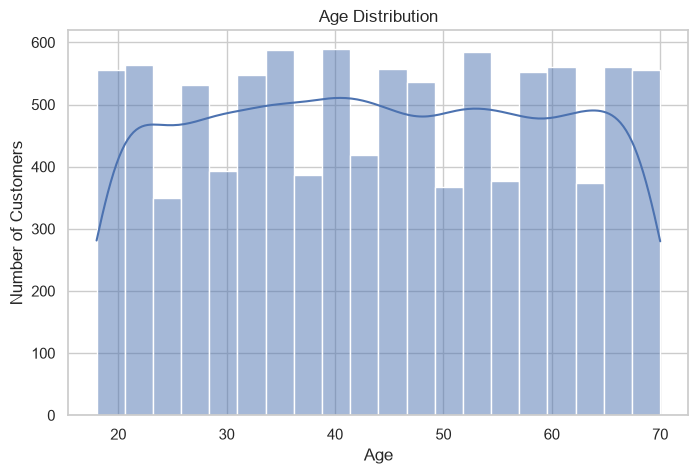

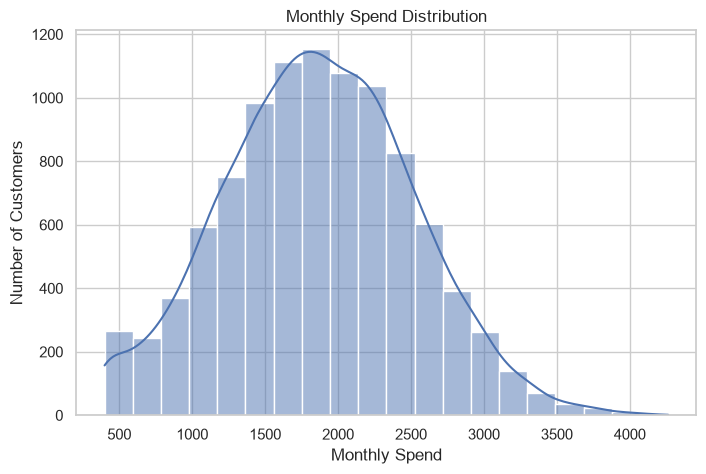

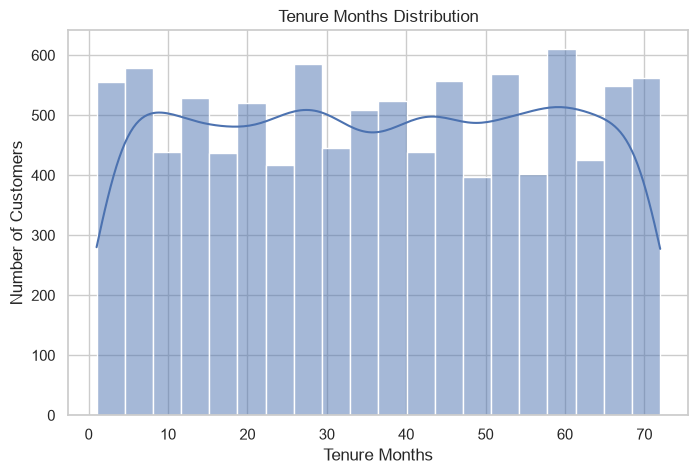

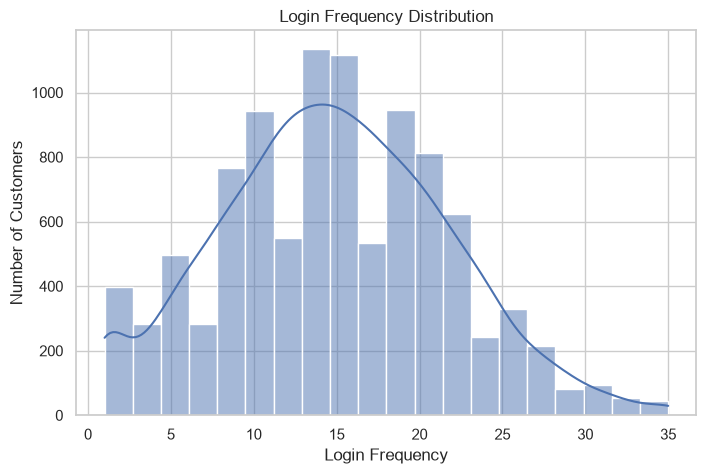

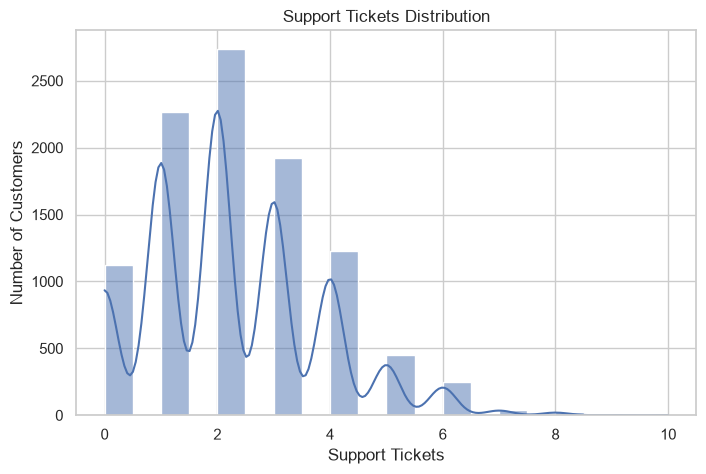

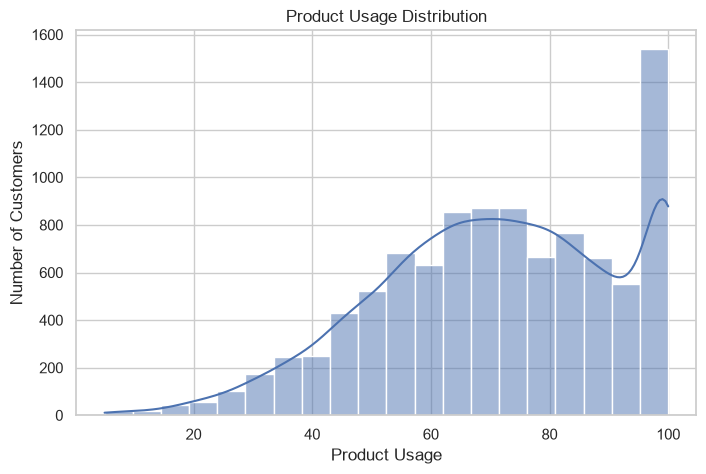

In [44]:
numerical_features = [
    "age",
    "monthly_spend",
    "tenure_months",
    "login_frequency",
    "support_tickets",
    "product_usage"
]

for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        bins=20,
        kde=True
    )

    plt.title(f"{feature.replace('_', ' ').title()} Distribution")
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Number of Customers")

    plt.show()

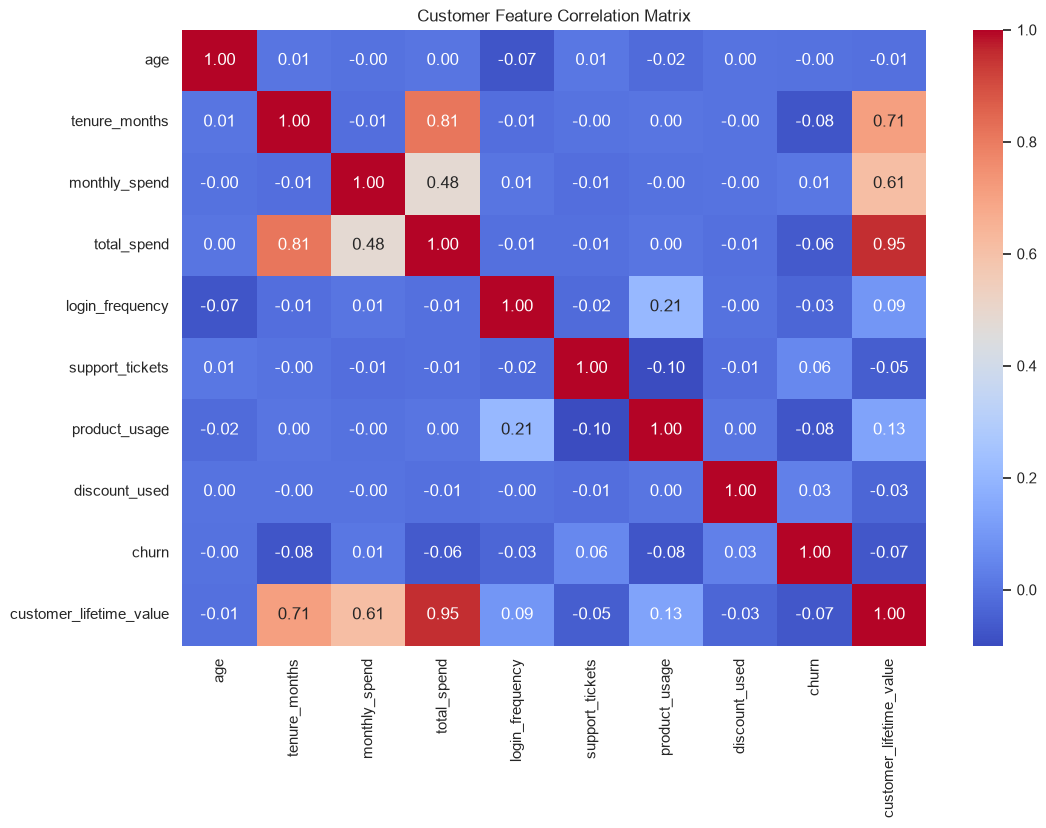

In [45]:
numeric_columns = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Feature Correlation Matrix")

plt.show()

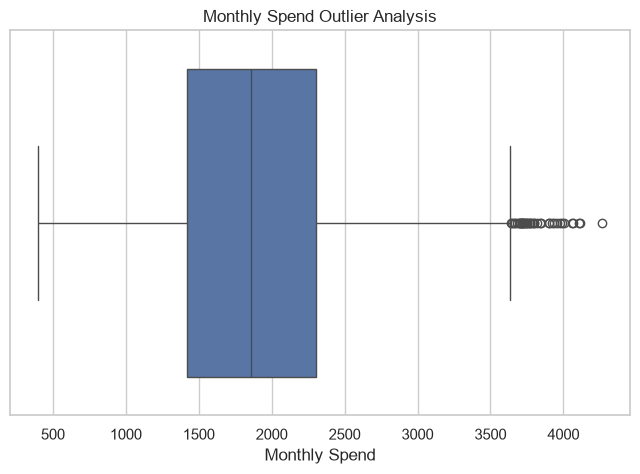

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="monthly_spend"
)

plt.title("Monthly Spend Outlier Analysis")
plt.xlabel("Monthly Spend")

plt.show()

In [48]:
Q1 = df["monthly_spend"].quantile(0.25)
Q3 = df["monthly_spend"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["monthly_spend"] < lower_bound) |
    (df["monthly_spend"] > upper_bound)
]

print(f"Number of outliers: {len(outliers)}")

Number of outliers: 41


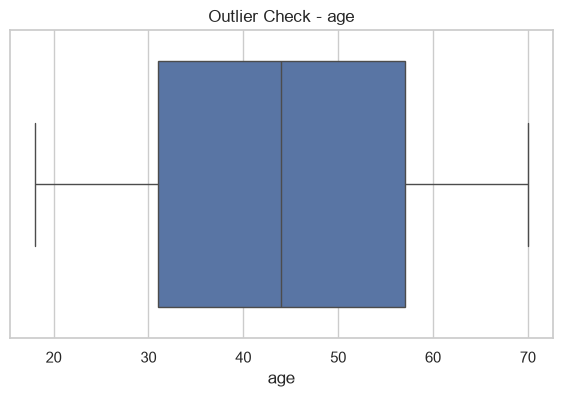

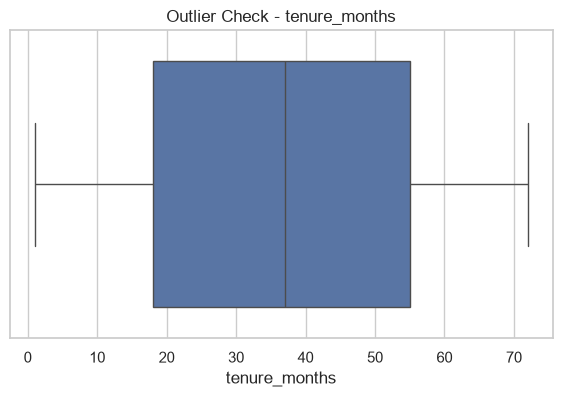

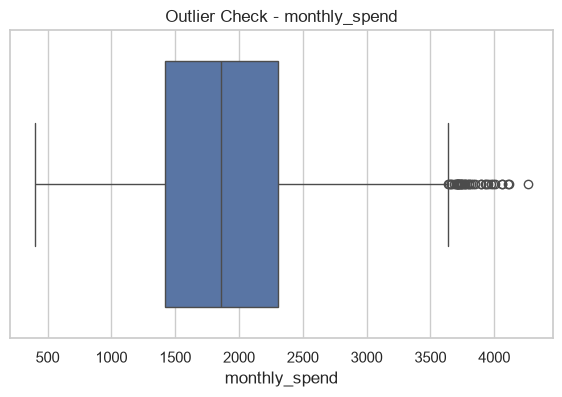

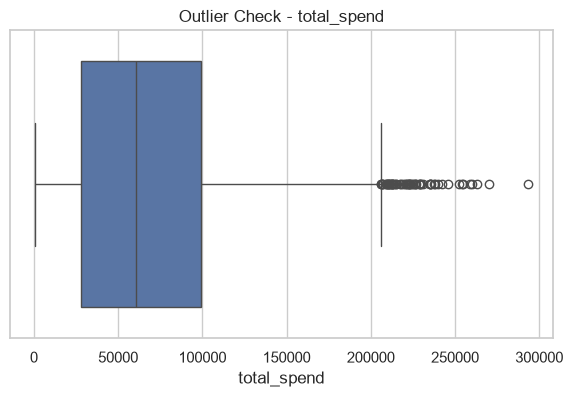

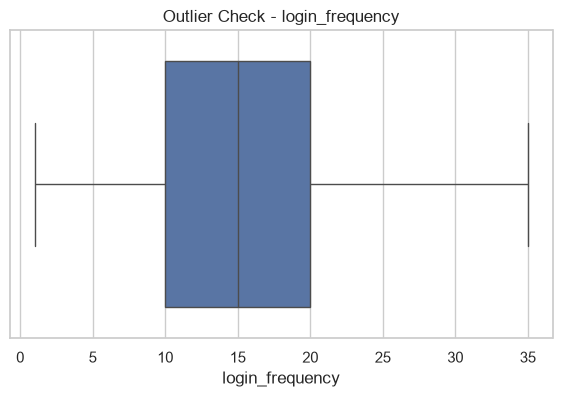

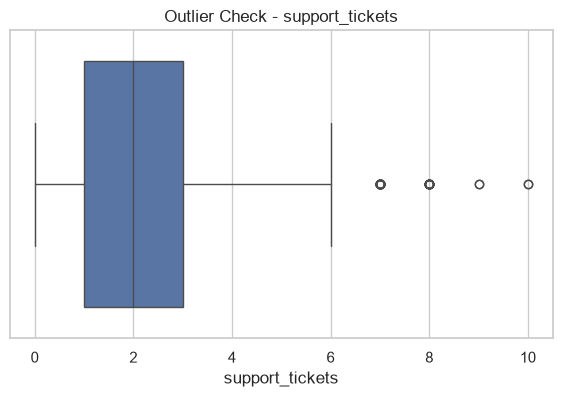

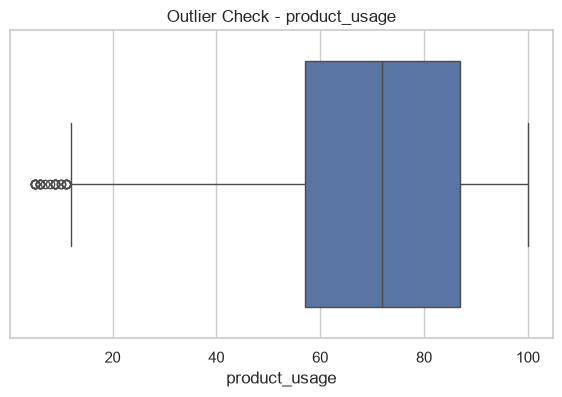

In [60]:
numerical_features = [
    "age",
    "tenure_months",
    "monthly_spend",
    "total_spend",
    "login_frequency",
    "support_tickets",
    "product_usage"
]

for column in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Outlier Check - {column}")
    plt.xlabel(column)
    plt.show()

In [61]:
subscription_churn = (
    pd.crosstab(
        df["subscription_type"],
        df["churn"],
        normalize="index"
    ) * 100
)

subscription_churn = subscription_churn.round(2)

print(subscription_churn)


churn                  0     1
subscription_type             
Annual             98.15  1.85
Monthly            97.30  2.70
Quarterly          96.94  3.06


In [62]:
gender_churn = (
    pd.crosstab(
        df["gender"],
        df["churn"],
        normalize="index"
    ) * 100
)

gender_churn = gender_churn.round(2)

print(gender_churn)

churn       0     1
gender             
Female  97.34  2.66
Male    97.59  2.41
Other   96.46  3.54


In [63]:
location_churn = (
    pd.crosstab(
        df["location"],
        df["churn"],
        normalize="index"
    ) * 100
)

location_churn = location_churn.round(2)

print(location_churn)

churn          0     1
location              
Bengaluru  97.61  2.39
Chennai    96.84  3.16
Delhi      97.99  2.01
Hyderabad  97.19  2.81
Kolkata    97.05  2.95
Mumbai     97.41  2.59
Other      98.02  1.98
Pune       97.53  2.47


In [64]:
payment_churn = (
    pd.crosstab(
        df["payment_method"],
        df["churn"],
        normalize="index"
    ) * 100
)

payment_churn = payment_churn.round(2)

print(payment_churn)

churn               0     1
payment_method             
Bank Transfer   97.67  2.33
Credit Card     98.17  1.83
Debit Card      96.82  3.18
UPI             97.22  2.78
Wallet          96.88  3.12


In [65]:
discount_churn = (
    pd.crosstab(
        df["discount_used"],
        df["churn"],
        normalize="index"
    ) * 100
)

discount_churn = discount_churn.round(2)

print(discount_churn)

churn              0     1
discount_used             
0              97.86  2.14
1              96.74  3.26


In [66]:
monthly_spend_by_churn = (
    df.groupby("churn")["monthly_spend"]
    .agg(["mean", "median", "std"])
    .round(2)
)

print(monthly_spend_by_churn)

          mean   median     std
churn                          
0      1864.09  1857.97  648.58
1      1899.22  1906.66  635.88


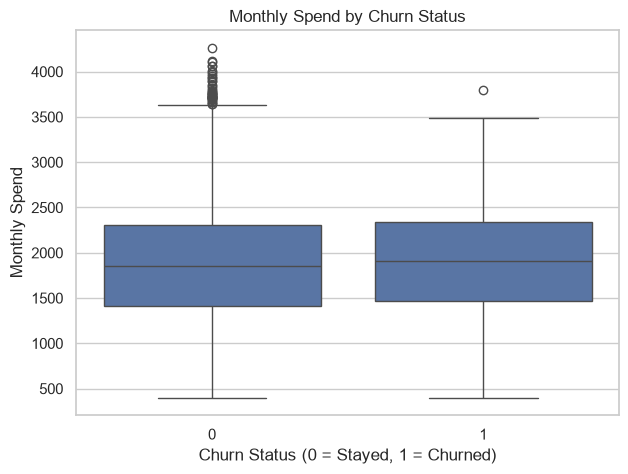

In [67]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="churn",
    y="monthly_spend",
    data=df
)

plt.title("Monthly Spend by Churn Status")
plt.xlabel("Churn Status (0 = Stayed, 1 = Churned)")
plt.ylabel("Monthly Spend")

plt.show()

In [68]:
tenure_by_churn = (
    df.groupby("churn")["tenure_months"]
    .agg(["mean", "median", "std"])
    .round(2)
)

print(tenure_by_churn)

        mean  median    std
churn                      
0      36.79    37.0  20.82
1      26.50    21.0  20.09


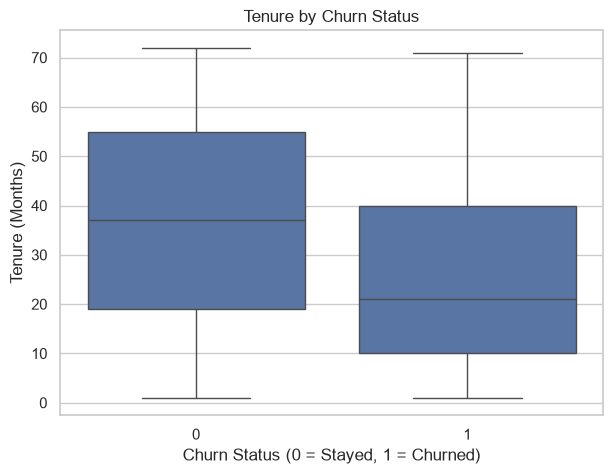

In [69]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="churn",
    y="tenure_months",
    data=df
)

plt.title("Tenure by Churn Status")
plt.xlabel("Churn Status (0 = Stayed, 1 = Churned)")
plt.ylabel("Tenure (Months)")

plt.show()

In [70]:
login_by_churn = (
    df.groupby("churn")["login_frequency"]
    .agg(["mean", "median", "std"])
    .round(2)
)

print(login_by_churn)

        mean  median   std
churn                     
0      14.90    15.0  6.88
1      13.43    13.0  6.24


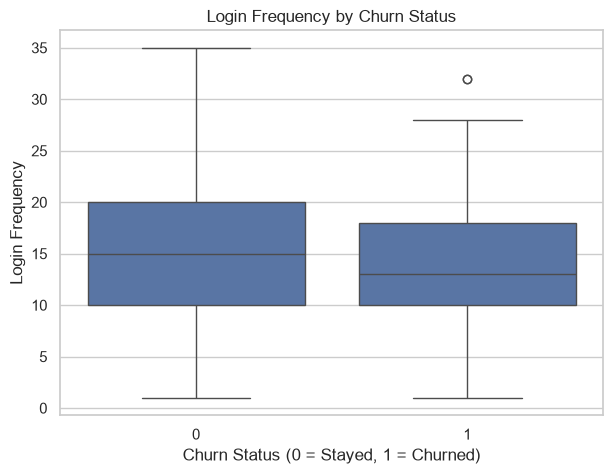

In [71]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="churn",
    y="login_frequency",
    data=df
)

plt.title("Login Frequency by Churn Status")
plt.xlabel("Churn Status (0 = Stayed, 1 = Churned)")
plt.ylabel("Login Frequency")

plt.show()

In [72]:
support_by_churn = (
    df.groupby("churn")["support_tickets"]
    .agg(["mean", "median", "std"])
    .round(2)
)

print(support_by_churn)

       mean  median   std
churn                    
0      2.24     2.0  1.51
1      2.80     2.0  1.68


In [74]:
churn_correlation = (
    df.select_dtypes(include=np.number)
    .corr()["churn"]
    .sort_values(ascending=False)
)

print(churn_correlation)

churn                      1.000000
support_tickets            0.057669
discount_used              0.034093
monthly_spend              0.008549
age                       -0.003852
login_frequency           -0.033714
total_spend               -0.062718
customer_lifetime_value   -0.071265
tenure_months             -0.077912
product_usage             -0.078404
Name: churn, dtype: float64


In [75]:
print("Numerical features most related to churn:")

print(
    churn_correlation.drop("churn")
    .abs()
    .sort_values(ascending=False)
)

Numerical features most related to churn:
product_usage              0.078404
tenure_months              0.077912
customer_lifetime_value    0.071265
total_spend                0.062718
support_tickets            0.057669
discount_used              0.034093
login_frequency            0.033714
monthly_spend              0.008549
age                        0.003852
Name: churn, dtype: float64


In [76]:
print("CUSTOMER CHURN EDA SUMMARY")
print("=" * 40)

print(f"Total Customers: {len(df)}")
print(f"Overall Churn Rate: {df['churn'].mean() * 100:.2f}%")

print(
    f"Average Monthly Spend: "
    f"{df['monthly_spend'].mean():.2f}"
)

print(
    f"Average Tenure: "
    f"{df['tenure_months'].mean():.2f} months"
)

print(
    f"Average Login Frequency: "
    f"{df['login_frequency'].mean():.2f}"
)

print(
    f"Average Support Tickets: "
    f"{df['support_tickets'].mean():.2f}"
)

print(
    f"Average Product Usage: "
    f"{df['product_usage'].mean():.2f}"
)

CUSTOMER CHURN EDA SUMMARY
Total Customers: 10050
Overall Churn Rate: 2.56%
Average Monthly Spend: 1864.99
Average Tenure: 36.53 months
Average Login Frequency: 14.86
Average Support Tickets: 2.26
Average Product Usage: 71.11


In [78]:
usage_by_churn = (
    df.groupby("churn")["product_usage"]
    .agg(["mean", "median", "std"])
    .round(2)
)

print(usage_by_churn)

        mean  median    std
churn                      
0      71.37    72.0  20.18
1      61.34    62.0  21.63
